#### 1) Importing Necessary Libraries:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, auc, roc_curve
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.pipeline import Pipeline

#### 2) Loading Data:

In [2]:
df = pd.read_csv('gene_expression.csv')

In [3]:
df.head()

,Gene One,Gene Two,Cancer Present
0,4.3,3.9,1
1,2.5,6.3,0
2,5.7,3.9,1
3,6.1,6.2,0
4,7.4,3.4,1


In [4]:
df.shape

(3000, 3)

In [5]:
df.describe()

,Gene One,Gene Two,Cancer Present
count,3000.000000,3000.000000,3000.000000
mean,5.600133,5.410467,0.500000
std,1.828388,1.729081,0.500083
min,1.000000,1.000000,0.000000
25%,4.300000,4.000000,0.000000
50%,5.600000,5.400000,0.500000
75%,6.900000,6.700000,1.000000
max,10.000000,10.000000,1.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gene One        3000 non-null   float64
 1   Gene Two        3000 non-null   float64
 2   Cancer Present  3000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 70.4 KB


#### 3) Data Cleaning and Transformations:

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gene One        3000 non-null   float64
 1   Gene Two        3000 non-null   float64
 2   Cancer Present  3000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 70.4 KB


- None of the features have Missing Values.
- Both features are Numeric and Continuous in Nature.

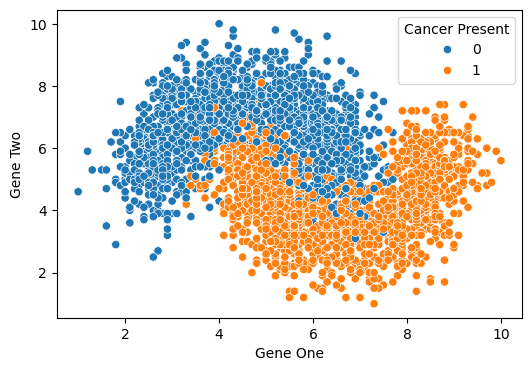

In [13]:
plt.figure(figsize= (6,4))
sns.scatterplot(data= df, x= 'Gene One', y= 'Gene Two', hue= 'Cancer Present')
plt.show()

##### 1) Gene One:

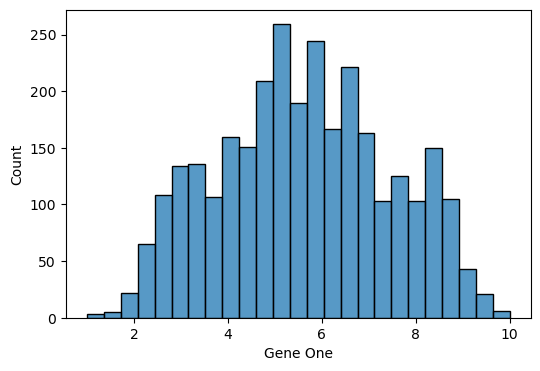

In [9]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'Gene One')
plt.show()

##### 2) Gene Two:

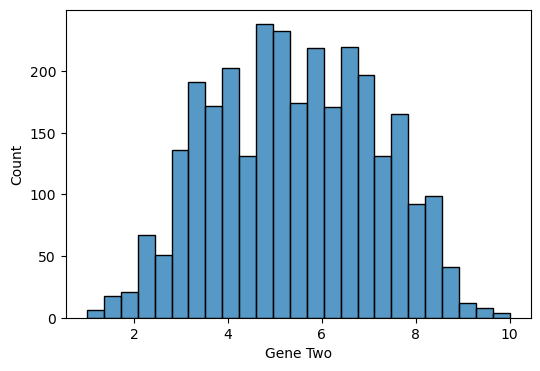

In [10]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'Gene Two')
plt.show()

- Both features have Normal Distributions.
- We will just have to Scale both the features. No other Transformations or Imputations are needed.

#### 4) Final Column Transformer:

In [11]:
preprocessor = ColumnTransformer([
    ('scaler', StandardScaler(), [0,1])
])

#### 5) Train Test Split:

In [14]:
X = df.drop('Cancer Present', axis= 1) # Features
y = df['Cancer Present'] # Target

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

In [16]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(2400, 2)
(600, 2)
(2400,)
(600,)


#### 6) Model Building and Evaluation: